# Image Preprocessing

This notebook is used to perform initial EDA on the training dataset and preprocess images. Note that preprocessing involves tiling of both the image and label datasets.

## Initial EDA

In [12]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [13]:
train_dir = "/Users/Ben/PycharmProjects/xBD_7150/train"
images_dir = os.path.join(train_dir, "images")
labels_dir = os.path.join(train_dir, "labels")
targets_dir = os.path.join(train_dir, "targets")

In [14]:
all_images = sorted(os.listdir(images_dir))
all_labels = sorted(os.listdir(labels_dir))
all_targets = sorted(os.listdir(targets_dir))

In [15]:
# Sanity Check
print("Total Files in Images: ", len(all_images))
print("Total Files in Labels: ", len(all_labels))
print("Total Files in Targets: ", len(all_targets))

Total Files in Images:  5598
Total Files in Labels:  5598
Total Files in Targets:  5598


In [16]:
pre_images = [i for i in all_images if "pre_disaster" in i]

post_images = [i for i in all_images if "post_disaster" in i]

# Half of Total Files
print(len(pre_images))

2799


In [17]:
# Extract Disaster Types
disaster_types = set()
for i in pre_images:
    parts = i.rsplit("_", 3)
    disaster_name = "_".join(i.split("_")[:-3])
    disaster_types.add(disaster_name)

In [18]:
print(disaster_types)

{'mexico-earthquake', 'hurricane-matthew', 'hurricane-florence', 'palu-tsunami', 'hurricane-michael', 'guatemala-volcano', 'hurricane-harvey', 'midwest-flooding', 'santa-rosa-wildfire', 'socal-fire'}


In [19]:
for d in disaster_types:
    count = len([i for i in pre_images if i.startswith(d)])
    print(f"{d}: {count} pairs")

mexico-earthquake: 121 pairs
hurricane-matthew: 238 pairs
hurricane-florence: 319 pairs
palu-tsunami: 113 pairs
hurricane-michael: 343 pairs
guatemala-volcano: 18 pairs
hurricane-harvey: 319 pairs
midwest-flooding: 279 pairs
santa-rosa-wildfire: 226 pairs
socal-fire: 823 pairs


In [20]:
# Print example image dimensions - (1024x1024x3) in the xBD documentation
img_path = os.path.join(images_dir, all_images[0])
img_dims = plt.imread(img_path).shape
print(f"Example image dimension: {img_dims}")

Example image dimension: (1024, 1024, 3)


## Tile data

In [23]:
from tiling import tile_image


image_dir = train_dir + "/images/"
label_dir = train_dir + "/labels/"

image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])
total_files = len(image_files)

# Only need to run once - uncomment below to run
for i, fname in enumerate(image_files):
    print(f"Tiling image {i+1} / {total_files}")
    img_path = os.path.join(image_dir, fname)
    # Get corresponding label
    lbl_path = os.path.join(label_dir, fname.replace(".png", ".json"))

    if not os.path.exists(lbl_path):
        print(f"No label found for {fname}, skipping")
        continue

    # Skip empty tiles (ie, tiles without buildings) to save space
    tile_image(img_path, lbl_path, skip_empty=True)

Tiling image 1 / 5598
Tiling image 2 / 5598
Tiling image 3 / 5598
Tiling image 4 / 5598
Tiling image 5 / 5598
Tiling image 6 / 5598
Tiling image 7 / 5598
Tiling image 8 / 5598
Tiling image 9 / 5598
Tiling image 10 / 5598
Tiling image 11 / 5598
Tiling image 12 / 5598
Tiling image 13 / 5598
Tiling image 14 / 5598
Tiling image 15 / 5598
Tiling image 16 / 5598
Tiling image 17 / 5598
Tiling image 18 / 5598
Tiling image 19 / 5598
Tiling image 20 / 5598
Tiling image 21 / 5598
Tiling image 22 / 5598
Tiling image 23 / 5598
Tiling image 24 / 5598
Tiling image 25 / 5598
Tiling image 26 / 5598
Tiling image 27 / 5598
Tiling image 28 / 5598
Tiling image 29 / 5598
Tiling image 30 / 5598
Tiling image 31 / 5598
Tiling image 32 / 5598
Tiling image 33 / 5598
Tiling image 34 / 5598
Tiling image 35 / 5598
Tiling image 36 / 5598
Tiling image 37 / 5598
Tiling image 38 / 5598
Tiling image 39 / 5598
Tiling image 40 / 5598
Tiling image 41 / 5598
Tiling image 42 / 5598
Tiling image 43 / 5598
Tiling image 44 / 55

In [24]:
# Confirm tiling output correct
tile_path = "/Users/Ben/PycharmProjects/xBD_7150/Preprocessing/tiles"
tile_img_dir = os.path.join(tile_path, "images")
tile_mask_dir = os.path.join(tile_path, "masks")
img_tiles = sorted(os.listdir(tile_img_dir))
mask_tiles = sorted(os.listdir(tile_mask_dir))

print("Total Files in tiles/images: ", len(img_tiles))
print("Total Files in tiles/masks: ", len(mask_tiles))
pre_images_tiles = [i for i in img_tiles if "pre_disaster" in i]
post_images_tiles = [i for i in img_tiles if "post_disaster" in i]

print(f"Total 'pre' tiles: {len(pre_images_tiles)}")
print(f"Total 'post' tiles: {len(post_images_tiles)}")

Total Files in tiles/images:  13811
Total Files in tiles/masks:  13811
Total 'pre' tiles: 6965
Total 'post' tiles: 6846


Note that there are more pre-disaster tiles than post-disaster tiles due to the skip_empty=True. This occurs when the post disaster tile does not contain any damaged buildings. Of course, without corresponding post-disaster tiles, these pre-disaster tiles cannot be used by the model. These tiles can therefore safely be deleted. Prior to their deletion, however, we will confirm which pre-disaster tiles do not have corresponding post-disaster tiles and that there are no post-disaster tiles without corresponding pre-disaster tiles.

In [25]:
unmatched_pre = [
    f for f in pre_images_tiles
    if f.replace("pre_disaster", "post_disaster") not in post_images_tiles
]
print(f"Unmatched pre tiles: {len(unmatched_pre)}")
print(f"Example unmatched pre tile: {unmatched_pre[0]}")

Unmatched pre tiles: 119
Example unmatched pre tile: hurricane-florence_00000057_pre_disaster_0_0.tif


In [26]:
# Confirm no unmatched post tiles
unmatched_post = [
    f for f in post_images_tiles
    if f.replace("post_disaster", "pre_disaster") not in pre_images_tiles
]
print(f"Unmatched post tiles: {len(unmatched_post)}")
for f in sorted(unmatched_post):
    print(f)

Unmatched post tiles: 0


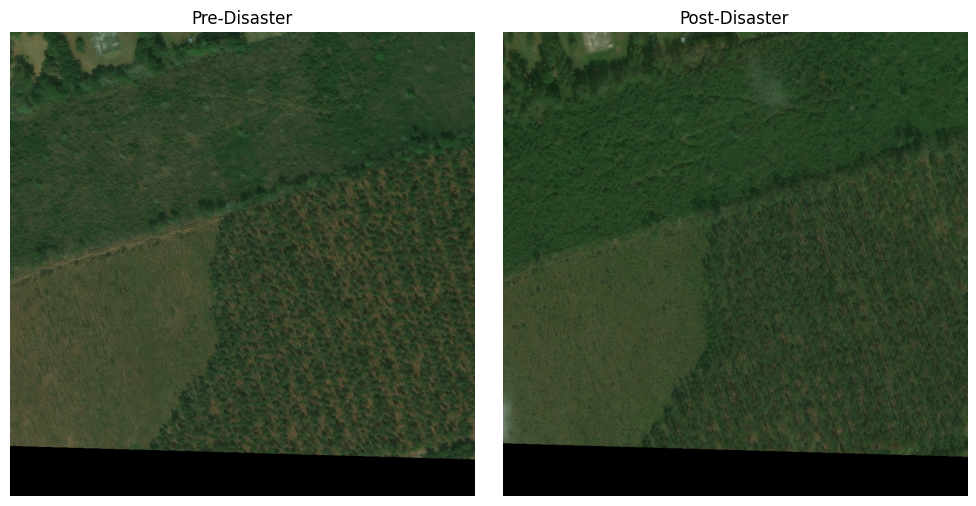

In [27]:
# Show example disaster with unmatched pre-disaster tile
pre_path = os.path.join(image_dir, "hurricane-florence_00000057_pre_disaster.png")
post_path = pre_path.replace("pre_disaster", "post_disaster")

pre = mpimg.imread(pre_path)
post = mpimg.imread(post_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(pre)
axes[0].set_title("Pre-Disaster")
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-Disaster")
axes[1].axis("off")

plt.tight_layout()
plt.show()

As expected, there were no damaged buildings in the post-disaster image for this example, hence the skipped post-disaster tile. The unmatched pre-disaster tiles will now be removed.

In [28]:
# Now can safely delete unmatched pre-disaster tiles (both images and their corresponding masks)
for fname in unmatched_pre:
    img_path = os.path.join(tile_img_dir, fname)
    mask_path = os.path.join(tile_mask_dir, fname)
    os.remove(img_path)
    os.remove(mask_path)

# Confirm deletion
print(f"Deleted {len(unmatched_pre)} unmatched pre-disaster image tiles and their corresponding masks")
final_img_tiles = sorted(os.listdir(tile_img_dir))
final_pre_images_tiles = [i for i in final_img_tiles if "pre_disaster" in i]
unmatched_pre = [
    f for f in final_pre_images_tiles
    if f.replace("pre_disaster", "post_disaster") not in post_images_tiles
]
print(f"Unmatched pre tiles: {len(unmatched_pre)}")


Deleted 119 unmatched pre-disaster image tiles and their corresponding masks
Unmatched pre tiles: 0
